Convergió en 2 iteraciones
Punto inicial : r=0.5000, θ=1.0472 rad
r óptimo      : 2.000000
θ óptimo      : 1.047198 rad  (60.0000°)
L máxima      : 0.703223


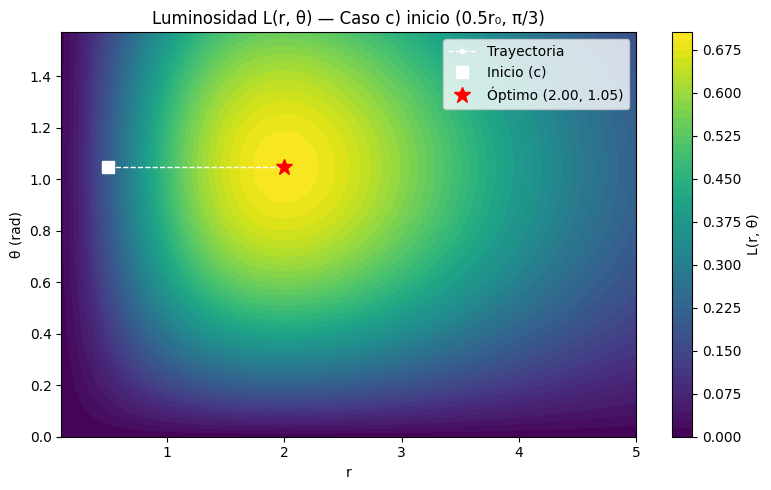

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
r0 = 1

def L(r, theta):
    return r**2 * np.sin(theta) * (1 + np.cos(theta)) * np.exp(-r / r0)

def ciclo_coordenadas(f, r0_init, theta0_init, tol=1e-6, max_iter=1000):
    """Optimización por ciclo de coordenadas (coordinate descent) para maximizar f."""
    r, theta = r0_init, theta0_init

    def golden_max_1d(g, a, b, eps=1e-8):
        phi = (np.sqrt(5) - 1) / 2
        x1 = b - phi * (b - a)
        x2 = a + phi * (b - a)
        f1, f2 = g(x1), g(x2)
        while (b - a) > eps:
            if f1 < f2:
                a = x1; x1 = x2; f1 = f2
                x2 = a + phi * (b - a); f2 = g(x2)
            else:
                b = x2; x2 = x1; f2 = f1
                x1 = b - phi * (b - a); f1 = g(x1)
        return (a + b) / 2

    historial = [(r, theta, f(r, theta))]

    for i in range(max_iter):
        r_prev, theta_prev = r, theta

        # Optimizar sobre r fijando theta
        r = golden_max_1d(lambda rv: f(rv, theta), 0.1, 5 * r0)

        # Optimizar sobre theta fijando r
        theta = golden_max_1d(lambda tv: f(r, tv), 0, np.pi / 2)

        historial.append((r, theta, f(r, theta)))

        if abs(r - r_prev) < tol and abs(theta - theta_prev) < tol:
            print(f"Convergió en {i+1} iteraciones")
            break

    return r, theta, f(r, theta), historial

# Caso c): punto inicial (0.5*r0, π/3)
r_init    = 0.5 * r0
theta_init = np.pi / 3

r_opt, theta_opt, L_max, hist = ciclo_coordenadas(L, r_init, theta_init)

print(f"Punto inicial : r={r_init:.4f}, θ={theta_init:.4f} rad")
print(f"r óptimo      : {r_opt:.6f}")
print(f"θ óptimo      : {theta_opt:.6f} rad  ({np.degrees(theta_opt):.4f}°)")
print(f"L máxima      : {L_max:.6f}")

# --- Gráfica: mapa de calor de L(r, θ) con trayectoria ---
r_vals     = np.linspace(0.1, 5, 300)
theta_vals = np.linspace(0, np.pi / 2, 300)
R, TH      = np.meshgrid(r_vals, theta_vals)
Z          = L(R, TH)

fig, ax = plt.subplots(figsize=(8, 5))
cp = ax.contourf(r_vals, theta_vals, Z, levels=50, cmap='viridis')
plt.colorbar(cp, ax=ax, label='L(r, θ)')

# Trayectoria del optimizador
rs     = [h[0] for h in hist]
thetas = [h[1] for h in hist]
ax.plot(rs, thetas, 'w--o', markersize=3, linewidth=1, label='Trayectoria')
ax.plot(r_init, theta_init, 'ws', markersize=8, label='Inicio (c)')
ax.plot(r_opt, theta_opt, 'r*', markersize=12, label=f'Óptimo ({r_opt:.2f}, {theta_opt:.2f})')

ax.set_xlabel('r')
ax.set_ylabel('θ (rad)')
ax.set_title('Luminosidad L(r, θ) — Caso c) inicio (0.5r₀, π/3)')
ax.legend()
plt.tight_layout()
plt.savefig('disco_acrecion_c.png', dpi=150)
plt.show()